# Overnight

In [230]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

gpt_headlines = pd.read_parquet('/Users/dylanpan/Documents/Full_Stack/p05_zhu-pan_2026/p05_zhu_pan_2026/_data/gpt_labels.parquet')
ravenpack = pd.read_parquet('/Users/dylanpan/Documents/Full_Stack/p05_zhu-pan_2026/p05_zhu_pan_2026/_data/ravenpack_intraday_story.parquet').drop_duplicates('rp_story_id')

gpt_headlines = gpt_headlines.merge(
    ravenpack,
    on=['rp_story_id', 'ticker'],
    how='left'
)

gpt_headlines.head()

,rp_story_id,ticker,headline,label,score,model,created_at,raw_response,prompt_version,timestamp_utc,timestamp_et,date,is_intraday,t15
0,EA417348B4D3EDADA36C0A6E1980F673,ALK,Alaska Air Stock Continues Rising Amid Expandi...,YES,1.0,gpt-4o-mini,,YES \nThe expansion of nonstop flight destina...,v1,2023-06-12 17:17:45.481,2023-06-12 13:17:45.481000-04:00,2023-06-12,True,2023-06-12 13:32:00-04:00
1,507420EDAA7082D904571033999590A9,ALK,Alaska Air Group reports second quarter 2023 r...,UNKNOWN,0.5,gpt-4o-mini,,UNKNOWN \nThe impact on ALK's stock price wil...,v1,2023-07-25 10:00:21.450,2023-07-25 06:00:21.450000-04:00,2023-07-25,False,2023-07-25 06:15:00-04:00
2,3F5946030352B03F97EB7CC5587C63D0,ALK,Alaska Airlines appoints new regional vice pre...,YES,1.0,gpt-4o-mini,,YES \nThe appointment of a new regional vice ...,v1,2023-08-30 12:00:06.109,2023-08-30 08:00:06.109000-04:00,2023-08-30,False,2023-08-30 08:15:00-04:00
3,0E4CA87C47957A438DC423C359D6A12D,ALK,Alaska Air Expects 3Q Revenue to Rise,YES,1.0,gpt-4o-mini,,YES \nAn expected rise in revenue typically i...,v1,2023-09-06 10:39:33.265,2023-09-06 06:39:33.265000-04:00,2023-09-06,False,2023-09-06 06:54:00-04:00
4,B53CAB41C4A1AA462371E1BD230882DD,ALK,Alaska Air Group reports third quarter 2023 re...,UNKNOWN,0.5,gpt-4o-mini,,UNKNOWN \nThe impact on ALK's stock price wil...,v1,2023-10-19 10:00:10.171,2023-10-19 06:00:10.171000-04:00,2023-10-19,False,2023-10-19 06:15:00-04:00


In [231]:
intraday_headlines = gpt_headlines[gpt_headlines['is_intraday'] == True]
intraday_headlines.head()

,rp_story_id,ticker,headline,label,score,model,created_at,raw_response,prompt_version,timestamp_utc,timestamp_et,date,is_intraday,t15
0,EA417348B4D3EDADA36C0A6E1980F673,ALK,Alaska Air Stock Continues Rising Amid Expandi...,YES,1.0,gpt-4o-mini,,YES \nThe expansion of nonstop flight destina...,v1,2023-06-12 17:17:45.481,2023-06-12 13:17:45.481000-04:00,2023-06-12,True,2023-06-12 13:32:00-04:00
7,87DE370472C75C4FACCC9702C9006447,ALK,Alaska Air Reaches Deal to Buy Hawaiian Airlin...,YES,1.0,gpt-4o-mini,,YES \nThe acquisition could enhance Alaska Ai...,v1,2023-12-03 20:53:16.387,2023-12-03 15:53:16.387000-05:00,2023-12-03,True,2023-12-03 16:08:00-05:00
58,4DA14B77F926D2E82CE9D15D008735B1,AEI,abrdn Equity Income Trust plc Third Interim Di...,YES,1.0,gpt-4o-mini,,YES \nThe announcement of a third interim div...,v1,2023-08-23 14:48:17.082,2023-08-23 10:48:17.082000-04:00,2023-08-23,True,2023-08-23 11:03:00-04:00
63,6647197B029A850F736C0DCCB7B24EB4,ULTA,"Ulta 1Q Earnings, Sales Set to Rise -- Earning...",YES,1.0,gpt-4o-mini,,YES \nThe expectation of rising earnings and ...,v1,2023-05-25 16:20:09.758,2023-05-25 12:20:09.758000-04:00,2023-05-25,True,2023-05-25 12:35:00-04:00
70,1D8376826ED20975D410B48155FC3911,ULTA,Ulta Beauty Seen Gaining Market Share Against ...,YES,1.0,gpt-4o-mini,,YES \nThis suggests positive momentum for Ult...,v1,2023-10-30 17:27:35.182,2023-10-30 13:27:35.182000-04:00,2023-10-30,True,2023-10-30 13:42:00-04:00


In [232]:
overnight_headlines = gpt_headlines[gpt_headlines['is_intraday'] == False]
overnight_headlines.head()

,rp_story_id,ticker,headline,label,score,model,created_at,raw_response,prompt_version,timestamp_utc,timestamp_et,date,is_intraday,t15
1,507420EDAA7082D904571033999590A9,ALK,Alaska Air Group reports second quarter 2023 r...,UNKNOWN,0.5,gpt-4o-mini,,UNKNOWN \nThe impact on ALK's stock price wil...,v1,2023-07-25 10:00:21.450,2023-07-25 06:00:21.450000-04:00,2023-07-25,False,2023-07-25 06:15:00-04:00
2,3F5946030352B03F97EB7CC5587C63D0,ALK,Alaska Airlines appoints new regional vice pre...,YES,1.0,gpt-4o-mini,,YES \nThe appointment of a new regional vice ...,v1,2023-08-30 12:00:06.109,2023-08-30 08:00:06.109000-04:00,2023-08-30,False,2023-08-30 08:15:00-04:00
3,0E4CA87C47957A438DC423C359D6A12D,ALK,Alaska Air Expects 3Q Revenue to Rise,YES,1.0,gpt-4o-mini,,YES \nAn expected rise in revenue typically i...,v1,2023-09-06 10:39:33.265,2023-09-06 06:39:33.265000-04:00,2023-09-06,False,2023-09-06 06:54:00-04:00
4,B53CAB41C4A1AA462371E1BD230882DD,ALK,Alaska Air Group reports third quarter 2023 re...,UNKNOWN,0.5,gpt-4o-mini,,UNKNOWN \nThe impact on ALK's stock price wil...,v1,2023-10-19 10:00:10.171,2023-10-19 06:00:10.171000-04:00,2023-10-19,False,2023-10-19 06:15:00-04:00
5,3CD8AEEEB67D56AF751AB3B9B4093909,ALK,VP Levine Acquires 598 Of Alaska Air Group Inc...,YES,1.0,gpt-4o-mini,,YES \nInsider buying can be seen as a positiv...,v1,2023-11-06 21:56:25.969,2023-11-06 16:56:25.969000-05:00,2023-11-07,False,2023-11-06 17:11:00-05:00


In [ ]:
daily_stock = pd.read_parquet('/Users/dylanpan/Documents/Full_Stack/p05_zhu-pan_2026/p05_zhu_pan_2026/_data/clean/crsp_daily.parquet')
daily_stock['date'] = pd.to_datetime(daily_stock['date'])

overnight_headlines['date'] = pd.to_datetime(overnight_headlines['date'])

# create unique daily stock dataframe with no duplicates
daily_stock_unique = (
    daily_stock
    .sort_values(['ticker','date'])
    .drop_duplicates(['ticker','date'], keep='first')
)




daily_stock_unique['prev_close'] = (
    daily_stock_unique
    .groupby('ticker')['closeprc']
    .shift(1)
)


cols = ['ticker', 'date', 'ret', 'openprc', 'closeprc', 'vol', 'prev_close']



overnight_headlines = overnight_headlines.merge(
    daily_stock_unique[cols],
    on=['ticker', 'date'],
    how='left'
)


# initial reaction = (open price - previous close price) / previous close price
overnight_headlines['initial_reaction'] = (overnight_headlines["openprc"] - overnight_headlines["prev_close"]) / overnight_headlines["prev_close"]

# drift = (close price - open price) / open price
overnight_headlines['drift'] =(overnight_headlines["closeprc"] - overnight_headlines["openprc"]) / overnight_headlines["openprc"]

# clean up columns
cols = ['ticker', 'headline', 'label', 'date', 'openprc', 'closeprc', 'prev_close', 'initial_reaction', 'drift']
overnight_headlines_cleaned = overnight_headlines[cols]

overnight_headlines_cleaned.dropna(inplace=True)

overnight_headlines_cleaned

/var/folders/3d/pvsnxml93pb9bss0st8xk04m0000gn/T/ipykernel_47440/985643257.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  overnight_headlines['date'] = pd.to_datetime(overnight_headlines['date'])
/var/folders/3d/pvsnxml93pb9bss0st8xk04m0000gn/T/ipykernel_47440/985643257.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  overnight_headlines_cleaned.dropna(inplace=True)


,ticker,headline,label,score,date,openprc,closeprc,prev_close,initial_reaction,drift
0,ALK,Alaska Air Group reports second quarter 2023 r...,UNKNOWN,0.5,2023-07-25,50.36,48.18,53.33,-0.055691,-0.043288
1,ALK,Alaska Airlines appoints new regional vice pre...,YES,1.0,2023-08-30,42.27,42.08,42.30,-0.000709,-0.004495
2,ALK,Alaska Air Expects 3Q Revenue to Rise,YES,1.0,2023-09-06,39.94,40.54,40.34,-0.009916,0.015023
3,ALK,Alaska Air Group reports third quarter 2023 re...,UNKNOWN,0.5,2023-10-19,33.10,32.16,32.66,0.013472,-0.028399
4,ALK,VP Levine Acquires 598 Of Alaska Air Group Inc...,YES,1.0,2023-11-07,33.02,33.16,32.84,0.005481,0.004240
...,...,...,...,...,...,...,...,...,...,...
112973,ALK,Alaska Air Group reports first quarter 2023 re...,UNKNOWN,0.5,2023-04-20,43.63,43.56,43.65,-0.000458,-0.001604
112974,ALK,Alaska Airlines launches partnership with STAR...,YES,1.0,2023-04-26,42.41,42.24,42.50,-0.002118,-0.004008
112975,ALK,STARLUX Airlines Announces First Airline Partn...,YES,1.0,2023-04-27,42.46,42.97,42.24,0.005208,0.012011
112976,ALK,Alaska Airlines slashes ticket prices to Dalla...,YES,1.0,2023-05-02,43.06,43.37,43.49,-0.009887,0.007199


In [94]:
def calculate_portfolio_metrics(
    df: pd.DataFrame,
    portfolio: str = "long_short",   # "long_short" | "long_only" | "short_only"
    min_long: int = 2,               # paper uses 2 for LS legs
    min_short: int = 2,
    annualization: int = 252,
) -> dict:


    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["signal"] = d["label"].map({"YES": 1, "NO": -1, "UNKNOWN": 0})

    # Drop neutrals
    d = d[d["signal"] != 0].copy()

    # Portfolio selection + per-stock portfolio return
    if portfolio == "long_short":
        # require both legs exist (paper-style)
        by_date = d.groupby("date")["signal"]
        long_n = by_date.apply(lambda x: (x > 0).sum())
        short_n = by_date.apply(lambda x: (x < 0).sum())
        valid_days = long_n[long_n >= min_long].index.intersection(
            short_n[short_n >= min_short].index
        )
        d = d[d["date"].isin(valid_days)].copy()

        d["port_initial"] = d["signal"] * d["initial_reaction"]
        d["port_drift"]   = d["signal"] * d["drift"]

    elif portfolio == "long_only":
        d = d[d["signal"] > 0].copy()

        # require at least min_long longs per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_long].index
        d = d[d["date"].isin(valid_days)].copy()

        d["port_initial"] = d["initial_reaction"]
        d["port_drift"]   = d["drift"]

    elif portfolio == "short_only":
        d = d[d["signal"] < 0].copy()

        # require at least min_short shorts per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_short].index
        d = d[d["date"].isin(valid_days)].copy()

        # short return = - stock return
        d["port_initial"] = -d["initial_reaction"]
        d["port_drift"]   = -d["drift"]

    else:
        raise ValueError("portfolio must be 'long_short', 'long_only', or 'short_only'")

    # Daily equal-weight portfolio return
    daily = d.groupby("date")[["port_initial", "port_drift"]].mean()

    # Metrics (fractions, not percent)
    hit_initial = (daily["port_initial"] > 0).mean()
    hit_drift   = (daily["port_drift"] > 0).mean()

    mean_initial = daily["port_initial"].mean()
    mean_drift   = daily["port_drift"].mean()

    # Sharpe (annualized) for drift (table reports drift Sharpe)
    vol_drift = daily["port_drift"].std()
    sharpe = np.nan if vol_drift == 0 or np.isnan(vol_drift) else (
        np.sqrt(annualization) * mean_drift / vol_drift
    )

    return {
        "portfolio": portfolio,
        "trading_days": int(daily.shape[0]),
        "hit_rate_initial": float(hit_initial),
        "hit_rate_drift": float(hit_drift),
        "mean_return_initial": float(mean_initial),
        "mean_return_drift": float(mean_drift),
        "sharpe_ratio_drift": float(sharpe) if sharpe == sharpe else np.nan,
    }


In [95]:
results_long_short = calculate_portfolio_metrics(overnight_headlines_cleaned, portfolio="long_short", min_long=2, min_short=2)
results_long_only = calculate_portfolio_metrics(overnight_headlines_cleaned, portfolio="long_only", min_long=2, min_short=2)
results_short_only = calculate_portfolio_metrics(overnight_headlines_cleaned, portfolio="short_only", min_long=2, min_short=2)

In [96]:
summary_df = pd.DataFrame([results_long_short, results_long_only, results_short_only])
summary_df

,portfolio,trading_days,hit_rate_initial,hit_rate_drift,mean_return_initial,mean_return_drift,sharpe_ratio_drift
0,long_short,658,0.887538,0.528875,0.010568,0.000623,1.008501
1,long_only,669,0.808670,0.502242,0.013549,0.000613,0.646856
2,short_only,658,0.756839,0.542553,0.004603,0.001439,1.055705


# Intraday

In [97]:
intraday_headlines['date'] = pd.to_datetime(intraday_headlines['date'])

daily_stock_unique = (
    daily_stock
    .sort_values(['ticker','date'])
    .drop_duplicates(['ticker','date'], keep='first')
)


daily_stock_unique['next_close'] = (
    daily_stock_unique
    .groupby('ticker')['closeprc']
    .shift(-1)
)


cols = ['ticker', 'date', 'ret', 'openprc', 'closeprc', 'vol', 'next_close']


intraday_headlines_drift = intraday_headlines.merge(
    daily_stock_unique[cols],
    on=['ticker', 'date'],
    how='left'
)

# build drift = (next close price - close price) / close price
intraday_headlines_drift['drift'] =(intraday_headlines_drift["next_close"] - intraday_headlines_drift["closeprc"]) / intraday_headlines_drift["closeprc"]

cols = ['ticker', 'headline', 'label', 'score', 'date', 'openprc', 'closeprc', 'next_close', 'drift']
intraday_headlines_drift = intraday_headlines_drift[cols]

intraday_headlines_drift.dropna(inplace=True)

intraday_headlines_drift

/var/folders/3d/pvsnxml93pb9bss0st8xk04m0000gn/T/ipykernel_47440/4143791935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intraday_headlines['date'] = pd.to_datetime(intraday_headlines['date'])


,ticker,headline,label,score,date,openprc,closeprc,next_close,drift
0,ALK,Alaska Air Stock Continues Rising Amid Expandi...,YES,1.0,2023-06-12,49.10000,49.58000,50.82000,0.025010
2,AEI,abrdn Equity Income Trust plc Third Interim Di...,YES,1.0,2023-08-23,1.29250,1.31330,1.35000,0.027945
3,ULTA,"Ulta 1Q Earnings, Sales Set to Rise -- Earning...",YES,1.0,2023-05-25,487.20999,485.12000,420.26999,-0.133678
4,ULTA,Ulta Beauty Seen Gaining Market Share Against ...,YES,1.0,2023-10-30,381.73999,379.23999,381.31000,0.005458
5,SPB,Superior Plus Announces January 2023 Cash Divi...,YES,1.0,2023-01-06,63.68000,62.90000,64.88000,0.031479
...,...,...,...,...,...,...,...,...,...
17836,BIIB,Reata Pharmaceuticals Stockholders Approve Mer...,YES,1.0,2023-09-21,258.79999,258.92999,257.67999,-0.004828
17837,SWK,Stanley Black & Decker To Present At The Baird...,UNKNOWN,0.5,2023-10-31,83.86000,85.05000,84.98000,-0.000823
17839,QCOM,"Athonet, Crosscall and Qualcomm join forces to...",YES,1.0,2023-03-01,123.78000,123.68000,123.78000,0.000809
17840,QCOM,"Qualcomm 2Q Earnings, Revenue Set to Fall -- E...",NO,0.0,2023-05-03,116.66000,112.83000,106.58000,-0.055393


In [98]:
def calculate_intraday_drift(
    df: pd.DataFrame,
    portfolio: str = "long_short",   # "long_short" | "long_only" | "short_only"
    min_long: int = 2,               # paper uses 2 for LS legs
    min_short: int = 2,
    annualization: int = 252,
) -> dict:


    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["signal"] = d["label"].map({"YES": 1, "NO": -1, "UNKNOWN": 0})

    # Drop neutrals
    d = d[d["signal"] != 0].copy()

    # Portfolio selection + per-stock portfolio return
    if portfolio == "long_short":
        # require both legs exist (paper-style)
        by_date = d.groupby("date")["signal"]
        long_n = by_date.apply(lambda x: (x > 0).sum())
        short_n = by_date.apply(lambda x: (x < 0).sum())
        valid_days = long_n[long_n >= min_long].index.intersection(
            short_n[short_n >= min_short].index
        )
        d = d[d["date"].isin(valid_days)].copy()

        d["port_drift"]   = d["signal"] * d["drift"]

    elif portfolio == "long_only":
        d = d[d["signal"] > 0].copy()

        # require at least min_long longs per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_long].index
        d = d[d["date"].isin(valid_days)].copy()

        d["port_drift"]   = d["drift"]

    elif portfolio == "short_only":
        d = d[d["signal"] < 0].copy()

        # require at least min_short shorts per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_short].index
        d = d[d["date"].isin(valid_days)].copy()

        # short return = - stock return
        d["port_drift"]   = -d["drift"]

    else:
        raise ValueError("portfolio must be 'long_short', 'long_only', or 'short_only'")

    # Daily equal-weight portfolio return
    daily = d.groupby("date")[["port_drift",]].mean()

    # Metrics (fractions, not percent)
    hit_drift   = (daily["port_drift"] > 0).mean()

    mean_drift   = daily["port_drift"].mean()

    # Sharpe (annualized) for drift (table reports drift Sharpe)
    vol_drift = daily["port_drift"].std()
    sharpe = np.nan if vol_drift == 0 or np.isnan(vol_drift) else (
        np.sqrt(annualization) * mean_drift / vol_drift
    )

    return {
        "portfolio": portfolio,
        "trading_days": int(daily.shape[0]),
        "hit_rate_drift": float(hit_drift),
        "mean_return_drift": float(mean_drift),
        "sharpe_ratio_drift": float(sharpe) if sharpe == sharpe else np.nan,
    }



In [99]:
intraday_drift_long_short = calculate_intraday_drift(intraday_headlines_drift, portfolio="long_short", min_long=2, min_short=2)
intraday_drift_long_only = calculate_intraday_drift(intraday_headlines_drift, portfolio="long_only", min_long=2, min_short=2)
intraday_drift_short_only = calculate_intraday_drift(intraday_headlines_drift, portfolio="short_only", min_long=2, min_short=2)
intraday_summary_df = pd.DataFrame([intraday_drift_long_short, intraday_drift_long_only, intraday_drift_short_only])
intraday_summary_df

,portfolio,trading_days,hit_rate_drift,mean_return_drift,sharpe_ratio_drift
0,long_short,623,0.524880,-0.395086,-1.152211
1,long_only,666,0.528529,0.001586,0.864315
2,short_only,623,0.500803,-2.170098,-1.016274


# Intraday initial response

In [173]:
intraday_headlines 

daily_stock_unique['prev_close'] = (
    daily_stock_unique
    .groupby('ticker')['closeprc']
    .shift(1)
)

cols = ['ticker', 'date', 'ret', 'openprc', 'closeprc', 'vol', 'next_close']

intraday_initial = intraday_headlines.merge(
    daily_stock_unique,
    on=['ticker', 'date'],
    how='left'
)

intraday_initial["minute_ts"] = (
    pd.to_datetime(intraday_initial["t15"])
    .dt.tz_localize(None)
)


cols = ['headline', 'timestamp_et','ticker', 'date', 'label', 'prev_close', 'minute_ts', 't15']

intraday_initial_cleaned = intraday_initial[cols]

intraday_initial_cleaned.dropna(inplace=True)
intraday_initial_cleaned


ValueError: You are trying to merge on object and datetime64[ns] columns for key 'date'. If you wish to proceed you should use pd.concat

In [101]:
taq = pd.read_parquet('/Users/dylanpan/Documents/Full_Stack/p05_zhu-pan_2026/p05_zhu_pan_2026/_data/taq_nbbo_minute.parquet')
taq['date'] = pd.to_datetime(taq['date'])

intraday_initial_cleaned = intraday_initial_cleaned.merge(taq,
                               on=['date', 'ticker', 'minute_ts'],
                               how='left')

intraday_initial_cleaned.dropna(inplace=True)

In [102]:
intraday_initial_cleaned['initial_reaction'] = (intraday_initial_cleaned['mid'] - intraday_initial_cleaned['prev_close']) / intraday_initial_cleaned['prev_close']
intraday_initial_cleaned

,headline,timestamp_et,ticker,date,label,prev_close,minute_ts,t15,mid,initial_reaction
0,Alaska Air Stock Continues Rising Amid Expandi...,2023-06-12 13:17:45.481000-04:00,ALK,2023-06-12,YES,48.65000,2023-06-12 13:32:00,2023-06-12 13:32:00-04:00,49.335,0.014080
2,"Ulta 1Q Earnings, Sales Set to Rise -- Earning...",2023-05-25 12:20:09.758000-04:00,ULTA,2023-05-25,YES,481.42999,2023-05-25 12:35:00,2023-05-25 12:35:00-04:00,485.490,0.008433
3,Ulta Beauty Seen Gaining Market Share Against ...,2023-10-30 13:27:35.182000-04:00,ULTA,2023-10-30,YES,379.87000,2023-10-30 13:42:00,2023-10-30 13:42:00-04:00,380.800,0.002448
4,Superior Plus Announces January 2023 Cash Divi...,2023-01-06 12:56:00.376000-05:00,SPB,2023-01-06,YES,63.00000,2023-01-06 13:11:00,2023-01-06 13:11:00-05:00,62.775,-0.003571
5,Superior Plus Announces March 2023 Cash Dividend,2023-03-09 11:46:00.211000-05:00,SPB,2023-03-09,YES,63.15000,2023-03-09 12:01:00,2023-03-09 12:01:00-05:00,62.140,-0.015994
...,...,...,...,...,...,...,...,...,...,...
16916,Reata Pharmaceuticals Stockholders Approve Mer...,2023-09-21 10:08:00.187000-04:00,BIIB,2023-09-21,YES,260.53000,2023-09-21 10:23:00,2023-09-21 10:23:00-04:00,259.660,-0.003339
16917,Stanley Black & Decker To Present At The Baird...,2023-10-31 11:18:12.377000-04:00,SWK,2023-10-31,UNKNOWN,84.24000,2023-10-31 11:33:00,2023-10-31 11:33:00-04:00,84.060,-0.002137
16918,"Athonet, Crosscall and Qualcomm join forces to...",2023-03-01 11:36:07.774000-05:00,QCOM,2023-03-01,YES,123.53000,2023-03-01 11:51:00,2023-03-01 11:51:00-05:00,123.860,0.002671
16919,"Qualcomm 2Q Earnings, Revenue Set to Fall -- E...",2023-05-03 09:30:00.050000-04:00,QCOM,2023-05-03,NO,116.11000,2023-05-03 09:45:00,2023-05-03 09:45:00-04:00,116.555,0.003833


In [107]:
def calculate_portfolio_initial(
    df: pd.DataFrame,
    portfolio: str = "long_short",   # "long_short" | "long_only" | "short_only"
    min_long: int = 2,               # paper uses 2 for LS legs
    min_short: int = 2,
    annualization: int = 252,
) -> dict:


    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["signal"] = d["label"].map({"YES": 1, "NO": -1, "UNKNOWN": 0})

    # Drop neutrals
    d = d[d["signal"] != 0].copy()

    # Portfolio selection + per-stock portfolio return
    if portfolio == "long_short":
        # require both legs exist (paper-style)
        by_date = d.groupby("date")["signal"]
        long_n = by_date.apply(lambda x: (x > 0).sum())
        short_n = by_date.apply(lambda x: (x < 0).sum())
        valid_days = long_n[long_n >= min_long].index.intersection(
            short_n[short_n >= min_short].index
        )
        d = d[d["date"].isin(valid_days)].copy()

        d["port_initial"] = d["signal"] * d["initial_reaction"]

    elif portfolio == "long_only":
        d = d[d["signal"] > 0].copy()

        # require at least min_long longs per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_long].index
        d = d[d["date"].isin(valid_days)].copy()

        d["port_initial"] = d["initial_reaction"]

    elif portfolio == "short_only":
        d = d[d["signal"] < 0].copy()

        # require at least min_short shorts per day (default 1; pass 2 if desired)
        counts = d.groupby("date").size()
        valid_days = counts[counts >= min_short].index
        d = d[d["date"].isin(valid_days)].copy()

        # short return = - stock return
        d["port_initial"] = -d["initial_reaction"]

    else:
        raise ValueError("portfolio must be 'long_short', 'long_only', or 'short_only'")

    # Daily equal-weight portfolio return
    daily = d.groupby("date")[["port_initial"]].mean()

    # Metrics (fractions, not percent)
    hit_initial = (daily["port_initial"] > 0).mean()

    mean_initial = daily["port_initial"].mean()

    # Sharpe (annualized) for drift (table reports drift Sharpe)

    return {
        "portfolio": portfolio,
        "trading_days": int(daily.shape[0]),
        "hit_rate_initial": float(hit_initial),
        "mean_return_initial": float(mean_initial),
    }

In [108]:
intraday_initial_long_short = calculate_portfolio_initial(intraday_initial_cleaned, portfolio="long_short", min_long=2, min_short=2)
intraday_initial_long_only = calculate_portfolio_initial(intraday_initial_cleaned, portfolio="long_only", min_long=2, min_short=2)
intraday_initial_short_only = calculate_portfolio_initial(intraday_initial_cleaned, portfolio="short_only", min_long=2, min_short=2)
intraday_initial_summary_df = pd.DataFrame([intraday_initial_long_short, intraday_initial_long_only, intraday_initial_short_only])
intraday_initial_summary_df

,portfolio,trading_days,hit_rate_initial,mean_return_initial
0,long_short,583,0.749571,0.015446
1,long_only,659,0.658574,0.017779
2,short_only,589,0.653650,0.006392


# overnight figure5

In [125]:
daily_stock_unique

,date,permno,ticker,comnam,shrcd,exchcd,ret,openprc,closeprc,vol,shrout,__index_level_0__,mktcap,next_open,next_close
3078,2021-10-01,87432,A,AGILENT TECHNOLOGIES INC,11,1,-0.009776,157.14999,155.99001,1881934.0,302723.0,3078,4.722176e+07,155.24001,152.36000
6873,2021-10-04,87432,A,AGILENT TECHNOLOGIES INC,11,1,-0.022027,155.24001,152.36000,1758404.0,302723.0,6873,4.612288e+07,153.48000,153.03000
11161,2021-10-05,87432,A,AGILENT TECHNOLOGIES INC,11,1,0.004397,153.48000,153.03000,1494305.0,302723.0,11161,4.632570e+07,152.55000,153.64999
13970,2021-10-06,87432,A,AGILENT TECHNOLOGIES INC,11,1,0.004051,152.55000,153.64999,1794778.0,302723.0,13970,4.651339e+07,155.06000,155.32001
18921,2021-10-07,87432,A,AGILENT TECHNOLOGIES INC,11,1,0.010869,155.06000,155.32001,1002863.0,302723.0,18921,4.701894e+07,156.17999,152.47000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2821604,2024-05-24,18418,ZYXI,ZYNEX INC,11,3,0.022352,10.29000,10.52000,84143.0,31775.0,321604,3.342730e+05,10.53000,10.11000
2824548,2024-05-28,18418,ZYXI,ZYNEX INC,11,3,-0.038974,10.53000,10.11000,140427.0,31775.0,324548,3.212452e+05,10.11000,10.02000
2828819,2024-05-29,18418,ZYXI,ZYNEX INC,11,3,-0.008902,10.11000,10.02000,121049.0,31775.0,328819,3.183855e+05,10.05000,9.92000
2834653,2024-05-30,18418,ZYXI,ZYNEX INC,11,3,-0.009980,10.05000,9.92000,160974.0,31775.0,334653,3.152080e+05,9.99000,10.15000


In [233]:
overnight_headlines

daily_stock = pd.read_parquet('/Users/dylanpan/Documents/Full_Stack/p05_zhu-pan_2026/p05_zhu_pan_2026/_data/clean/crsp_daily.parquet')
daily_stock['date'] = pd.to_datetime(daily_stock['date'])

overnight_headlines['date'] = pd.to_datetime(overnight_headlines['date'])

# create unique daily stock dataframe with no duplicates
daily_stock_unique = (
    daily_stock
    .sort_values(['ticker','date'])
    .drop_duplicates(['ticker','date'], keep='first')
)


daily_stock_unique['next_open'] = (
    daily_stock_unique
    .groupby('ticker')['openprc']
    .shift(-1)
)

daily_stock_unique['next_close'] = (
    daily_stock_unique
    .groupby('ticker')['closeprc']
    .shift(-1)
)

daily_stock_unique['prior_close'] = (
    daily_stock_unique
    .groupby('ticker')['closeprc']
    .shift(1)
)


cols = ['exchcd', 'ticker', 'date', 'ret', 'openprc', 'closeprc', 'vol', 'next_open', 'next_close', 'prior_close', 'mktcap']


overnight_headlines = overnight_headlines.merge(
    daily_stock_unique[cols],
    on=['ticker', 'date'],
    how='left'
)

In [234]:
cols = ['exchcd', 'ticker', 'date', 'headline', 'label', 'openprc', 'closeprc', 'timestamp_et', 'next_open', 'next_close', 'prior_close', 'mktcap']
overnight_headlines_cleaned = overnight_headlines[cols]
overnight_headlines_cleaned.dropna(inplace=True)
overnight_headlines_cleaned['timestamp_et'] = pd.to_datetime(overnight_headlines_cleaned['timestamp_et']).dt.tz_localize(None)

In [235]:
overnight_headlines_cleaned["timestamp_et"] = pd.to_datetime(
    overnight_headlines_cleaned["timestamp_et"]
)

# classify
overnight_headlines_cleaned["before_open"] = (
    overnight_headlines_cleaned["timestamp_et"].dt.time < pd.to_datetime("09:00").time()
)

overnight_headlines_cleaned["after_close"] = (
    overnight_headlines_cleaned["timestamp_et"].dt.time > pd.to_datetime("16:00").time()
)

overnight_headlines_cleaned['same_day_return'] = (overnight_headlines_cleaned['closeprc'] - overnight_headlines_cleaned['openprc']) / overnight_headlines_cleaned['openprc']
overnight_headlines_cleaned['next_day_return'] = (overnight_headlines_cleaned['next_close'] - overnight_headlines_cleaned['next_open']) / overnight_headlines_cleaned['next_open']

In [236]:
overnight_headlines_cleaned

,exchcd,ticker,date,headline,label,openprc,closeprc,timestamp_et,next_open,next_close,prior_close,mktcap,before_open,after_close,same_day_return,next_day_return
0,1.0,ALK,2023-07-25,Alaska Air Group reports second quarter 2023 r...,UNKNOWN,50.36,48.18,2023-07-25 06:00:21.450,48.06,47.86,53.33,6162751.98,True,False,-0.043288,-0.004161
1,1.0,ALK,2023-08-30,Alaska Airlines appoints new regional vice pre...,YES,42.27,42.08,2023-08-30 08:00:06.109,42.41,41.97,42.30,5382494.88,True,False,-0.004495,-0.010375
2,1.0,ALK,2023-09-06,Alaska Air Expects 3Q Revenue to Rise,YES,39.94,40.54,2023-09-06 06:39:33.265,40.34,40.02,40.34,5157660.96,True,False,0.015023,-0.007933
3,1.0,ALK,2023-10-19,Alaska Air Group reports third quarter 2023 re...,UNKNOWN,33.10,32.16,2023-10-19 06:00:10.171,32.08,32.02,32.66,4091523.84,True,False,-0.028399,-0.001870
4,1.0,ALK,2023-11-07,VP Levine Acquires 598 Of Alaska Air Group Inc...,YES,33.02,33.16,2023-11-06 16:56:25.969,33.36,33.92,32.84,4218747.84,False,True,0.004240,0.016787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112973,1.0,ALK,2023-04-20,Alaska Air Group reports first quarter 2023 re...,UNKNOWN,43.63,43.56,2023-04-20 06:00:11.152,44.09,44.41,43.65,5555729.52,True,False,-0.001604,0.007258
112974,1.0,ALK,2023-04-26,Alaska Airlines launches partnership with STAR...,YES,42.41,42.24,2023-04-26 08:00:15.635,42.46,42.97,42.50,5387374.08,True,False,-0.004008,0.012011
112975,1.0,ALK,2023-04-27,STARLUX Airlines Announces First Airline Partn...,YES,42.46,42.97,2023-04-27 09:00:00.955,43.09,43.46,42.24,5480479.74,False,False,0.012011,0.008587
112976,1.0,ALK,2023-05-02,Alaska Airlines slashes ticket prices to Dalla...,YES,43.06,43.37,2023-05-01 19:22:35.620,43.45,43.47,43.49,5531496.54,False,True,0.007199,0.000460


In [ ]:
def long_short_strategy(df):
    df = df.copy()

    # keep tradable timing only
    df = df[df["before_open"] | df["after_close"]].copy()

    # keep only YES / NO
    df = df[df["label"].isin(["YES", "NO"])].copy()

    # choose event return
    df["event_return"] = np.where(
        df["before_open"],
        df["same_day_return"],
        df["next_day_return"]
    )

    # collapse to one firm-day observation
    # here: average multiple headlines for same stock-day-label bucket
    df["date"] = pd.to_datetime(df["date"])
    firmday = (
        df.groupby(["date", "ticker", "label"], as_index=False)["event_return"]
        .mean()
    )

    # split long and short legs
    long_df = (
        firmday[firmday["label"] == "YES"]
        .groupby("date")["event_return"]
        .mean()
        .rename("long_ret")
    )

    short_df = (
        firmday[firmday["label"] == "NO"]
        .groupby("date")["event_return"]
        .mean()
        .rename("short_ret")
    )

    daily = pd.concat([long_df, short_df], axis=1)

    # if one side missing on a day, set to 0 or drop; paper choice matters
    daily = daily.fillna(0)

    daily["ls_ret"] = daily["long_ret"] - daily["short_ret"]
    cumulative = (1 + daily["ls_ret"]).cumprod()

    return cumulative

In [ ]:
def long_short_not_small(df):

    df = df.copy()

    # tradable event timing
    df = df[df["before_open"] | df["after_close"]]

    # only tradable labels
    df = df[df["label"].isin(["YES","NO"])]

    # choose correct return
    df["event_return"] = np.where(
        df["before_open"],
        df["same_day_return"],
        df["next_day_return"]
    )

    # compute NYSE 20th percentile breakpoint each day
    nyse_bp = (
        df[df["exchcd"] == 1]
        .groupby("date")["mktcap"]
        .quantile(0.20)
        .rename("nyse_bp")
    )

    df = df.merge(nyse_bp, on="date", how="left")

    # keep only not-small stocks
    df = df[df["mktcap"] > df["nyse_bp"]]

    # signal
    df["signal"] = df["label"].map({"YES":1,"NO":-1})

    # firm-day aggregation
    firmday = (
        df.groupby(["date","ticker"])
        .agg(
            signal=("signal","mean"),
            event_return=("event_return","mean")
        )
        .reset_index()
    )

    # long and short legs
    long_ret = firmday[firmday["signal"]>0].groupby("date")["event_return"].mean()
    short_ret = firmday[firmday["signal"]<0].groupby("date")["event_return"].mean()

    daily = pd.concat([long_ret,short_ret],axis=1).fillna(0)
    daily.columns = ["long","short"]

    daily["ls_ret"] = daily["long"] - daily["short"]

    return (1 + daily["ls_ret"]).cumprod() * 2


def long_short_greater_5(df):

    df = df.copy()

    df = df[df["before_open"] | df["after_close"]]
    df = df[df["label"].isin(["YES","NO"])]

    df["event_return"] = np.where(
        df["before_open"],
        df["same_day_return"],
        df["next_day_return"]
    )

    # price filter
    df = df[df["prior_close"] > 5]

    df["signal"] = df["label"].map({"YES":1,"NO":-1})

    firmday = (
        df.groupby(["date","ticker"])
        .agg(
            signal=("signal","mean"),
            event_return=("event_return","mean")
        )
        .reset_index()
    )

    long_ret = firmday[firmday["signal"]>0].groupby("date")["event_return"].mean()
    short_ret = firmday[firmday["signal"]<0].groupby("date")["event_return"].mean()

    daily = pd.concat([long_ret,short_ret],axis=1).fillna(0)
    daily.columns = ["long","short"]

    daily["ls_ret"] = daily["long"] - daily["short"]

    return (1 + daily["ls_ret"]).cumprod() 

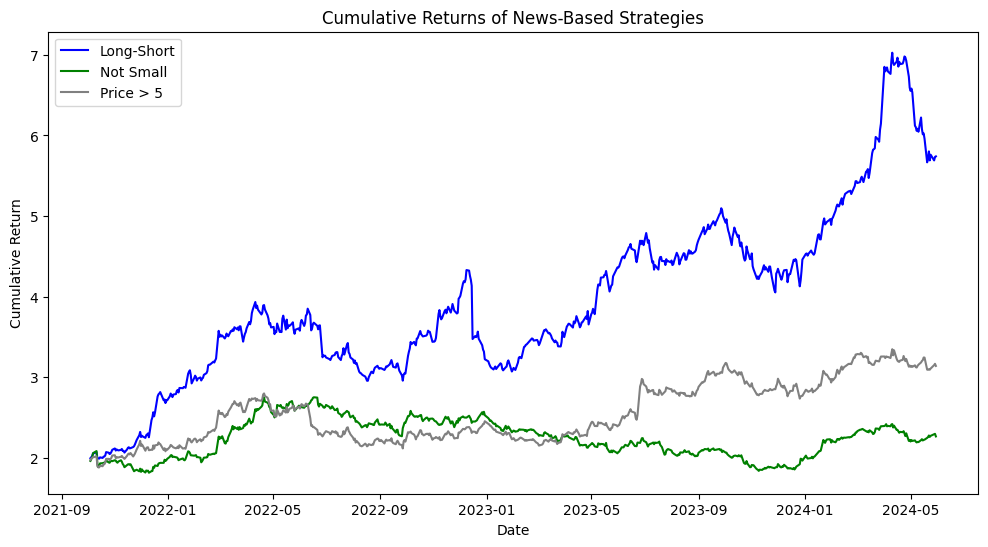

In [245]:
cumret_long_short_blue = long_short_strategy(overnight_headlines_cleaned)
cumret_not_small_green = long_short_not_small(overnight_headlines_cleaned)
cumret_price5_grey = long_short_greater_5(overnight_headlines_cleaned)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(cumret_long_short_blue.index, cumret_long_short_blue, label='Long-Short', color='blue')
plt.plot(cumret_not_small_green.index, cumret_not_small_green, label='Not Small', color='green')
plt.plot(cumret_price5_grey.index, cumret_price5_grey, label='Price > 5', color='grey')

plt.title("Cumulative Returns of News-Based Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

plt.show()

In [228]:
cumret_long_short_blue

date
2021-10-01    1.016589
2021-10-04    1.012186
2021-10-05    1.018904
2021-10-06    1.025319
2021-10-07    1.043313
Name: ls_ret, dtype: float64